# Experimento: PSBPM-FD conjunto — resumen

Una tabla por bloque con los cuatro casos, leída de `reports/`. Los detalles están en los notebooks `E_0x` de cada carpeta y en `README.md`.

- **Bloque A**: razón de cada modelo contra el FAR(2) (`kn` por hold-out) en test, promediada por ventana (w = 30), y % de ventanas que gana en MAE.
- **Bloque B**: Winkler (primaria), PICP, PICPB y MPIW en test por banda, y % de ventanas que gana en Winkler.
- **Convergencia**: R-hat de las cantidades invariantes a la permutación y cuántas π_j no convergen.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
sys.path.insert(0, str(Path.cwd().resolve()))
from mv_psbp import resumen
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)


## Bloque A (test)

In [2]:
display(resumen.bloque_A("test").round(3))
display(resumen.info())

,caso,modelo,MAE/FAR,RMSE/FAR,Emax_prom/FAR,pct_ventanas_MAE
0,200 TAR,PSBPM-FD conjunto,0.928,0.927,0.964,0.000
1,200 TAR,FAR,1.000,1.000,1.000,0.000
2,200 TAR,PSBPM-FD univariado,0.789,0.792,0.821,1.000
3,201 GARCH,PSBPM-FD conjunto,0.996,0.998,0.992,0.199
4,201 GARCH,FAR,1.000,1.000,1.000,0.041
5,201 GARCH,PSBPM-FD univariado,0.987,0.987,0.981,0.760
6,202 MULT,PSBPM-FD conjunto,1.004,1.004,0.998,0.138
7,202 MULT,FAR,1.000,1.000,1.000,0.078
8,202 MULT,PSBPM-FD univariado,0.985,0.983,0.977,0.784
9,real eolica DE,PSBPM-FD conjunto,1.002,1.001,0.999,0.500


,caso,far_kn,far_p,far_radio_espectral,n_origenes,univariado
0,200 TAR,9,2,0.6298899552295393,996,M=10 de la corrida viva
1,201 GARCH,5,2,0.6906373152817352,996,M=10 de la corrida viva
2,202 MULT,8,2,0.8434393967974945,998,M=6 de la corrida viva
3,real eolica DE,12.0,2.0,0.866674,4297.0,NaN
4,200 TAR bloque,9,2,0.6298899552295393,996,M=10 de la corrida viva
5,201 GARCH bloque,5,2,0.6906373152817352,996,M=10 de la corrida viva
6,202 MULT bloque,8,2,0.8434393967974945,998,M=6 de la corrida viva


## Bloque B (test)

In [3]:
display(resumen.bloque_B("test").round(3))

,caso,banda,winkler,picp,picp_simultaneo,mpiw,pct_ventanas_winkler
0,200 TAR,FAR (IC gaussiano),4.975,0.941,0.681,3.840,0.000
1,200 TAR,PSBPM-FD conjunto (predictiva nativa),4.483,0.961,0.707,3.897,0.000
2,200 TAR,PSBPM-FD univariado (predictiva nativa),3.909,0.969,0.692,3.578,1.000
3,201 GARCH,FAR (IC gaussiano),4.326,0.943,0.641,3.436,0.225
4,201 GARCH,PSBPM-FD conjunto (predictiva nativa),4.315,0.946,0.645,3.501,0.243
5,201 GARCH,PSBPM-FD univariado (predictiva nativa),4.228,0.947,0.650,3.486,0.532
6,202 MULT,FAR (IC gaussiano),4.238,0.935,0.557,3.264,0.149
7,202 MULT,PSBPM-FD conjunto (predictiva nativa),4.190,0.941,0.580,3.381,0.234
8,202 MULT,PSBPM-FD univariado (predictiva nativa),4.106,0.944,0.581,3.326,0.617
9,real eolica DE,FAR (IC gaussiano),0.579,0.943,0.759,0.447,0.114


## Convergencia

In [4]:
display(resumen.convergencia().round(3))

,caso,rhat_loglik,rhat_mse_in,rhat_N_activos,rhat_entropia,ess_min_mse_in,N_activos,entropia,pi_j_no_converge,pi_j_total
0,200 TAR,1.433,8.953,1.447,5.967,13.119,3.864,0.419,15,20
1,201 GARCH,1.097,1.006,1.022,1.008,1460.373,11.266,0.043,15,20
2,202 MULT,1.017,1.000,1.017,1.026,3255.366,7.305,0.032,4,20
3,real eolica DE,1.001,1.002,NaN,1.019,308.211,2.000,0.494,11,24
4,200 TAR bloque,1.472,2.367,1.635,4.466,16.619,9.255,1.363,7,20
5,201 GARCH bloque,1.031,1.028,1.053,1.001,171.090,12.440,0.408,19,20
6,202 MULT bloque,2.563,2.252,1.019,1.872,68.997,6.685,0.741,10,20


## Figuras 76/77 por caso

200 TAR 76_ganador_bloqueA.png


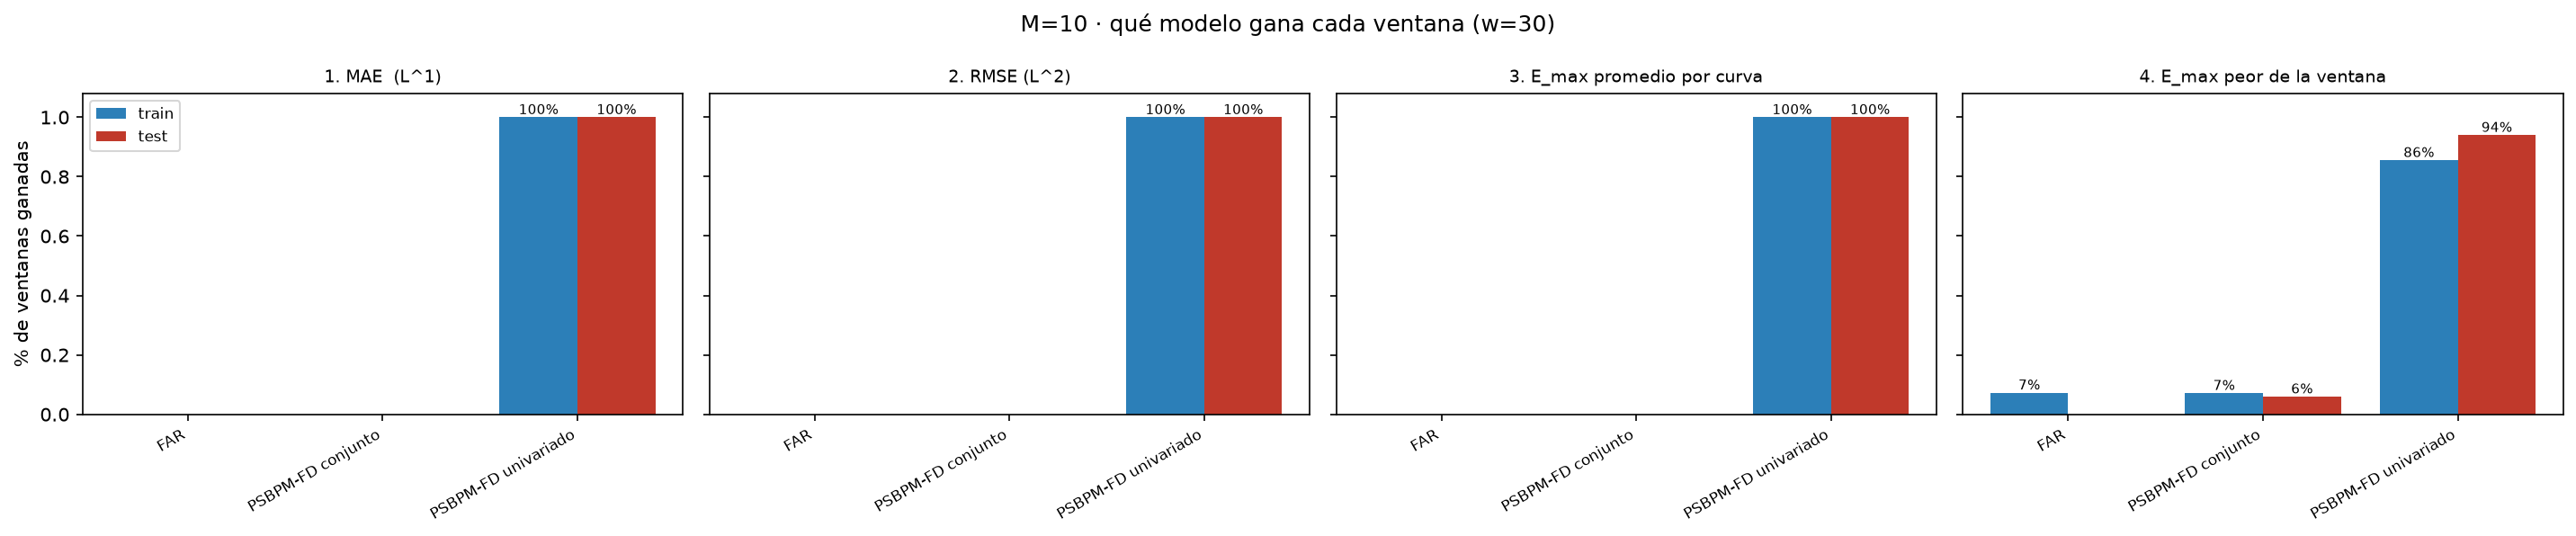

200 TAR 77_ganador_bloqueB.png


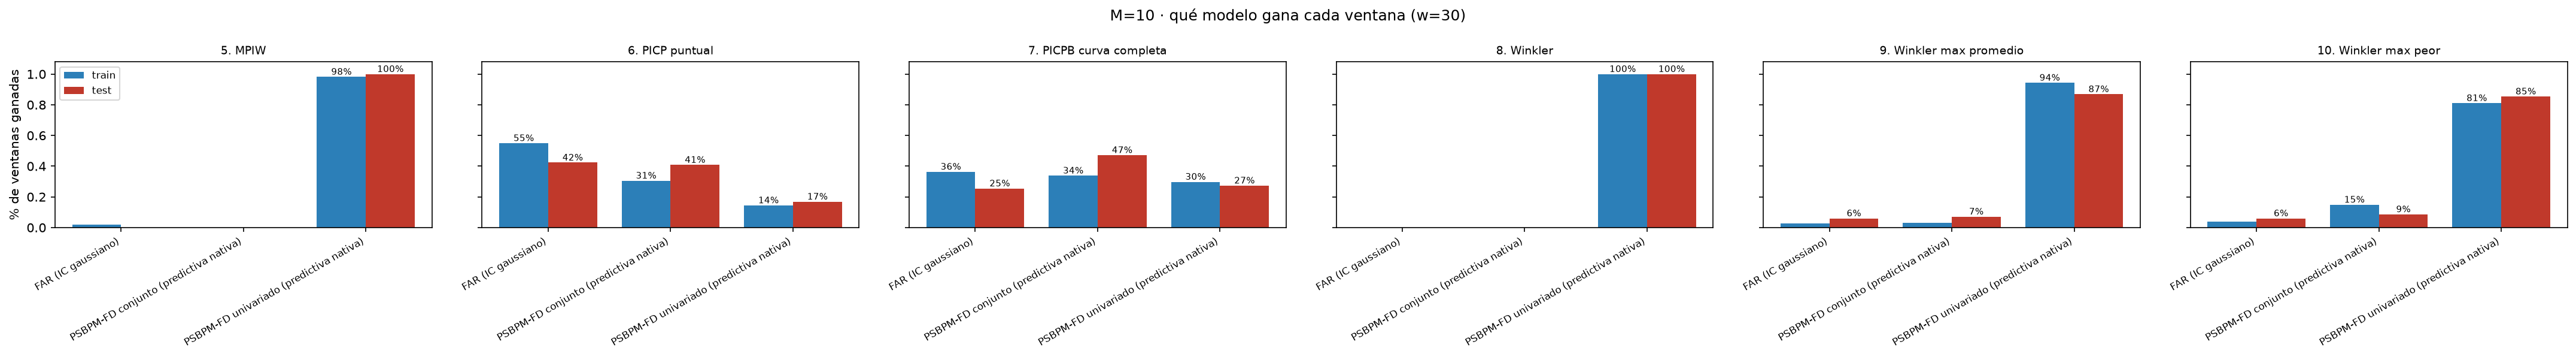

201 GARCH 76_ganador_bloqueA.png


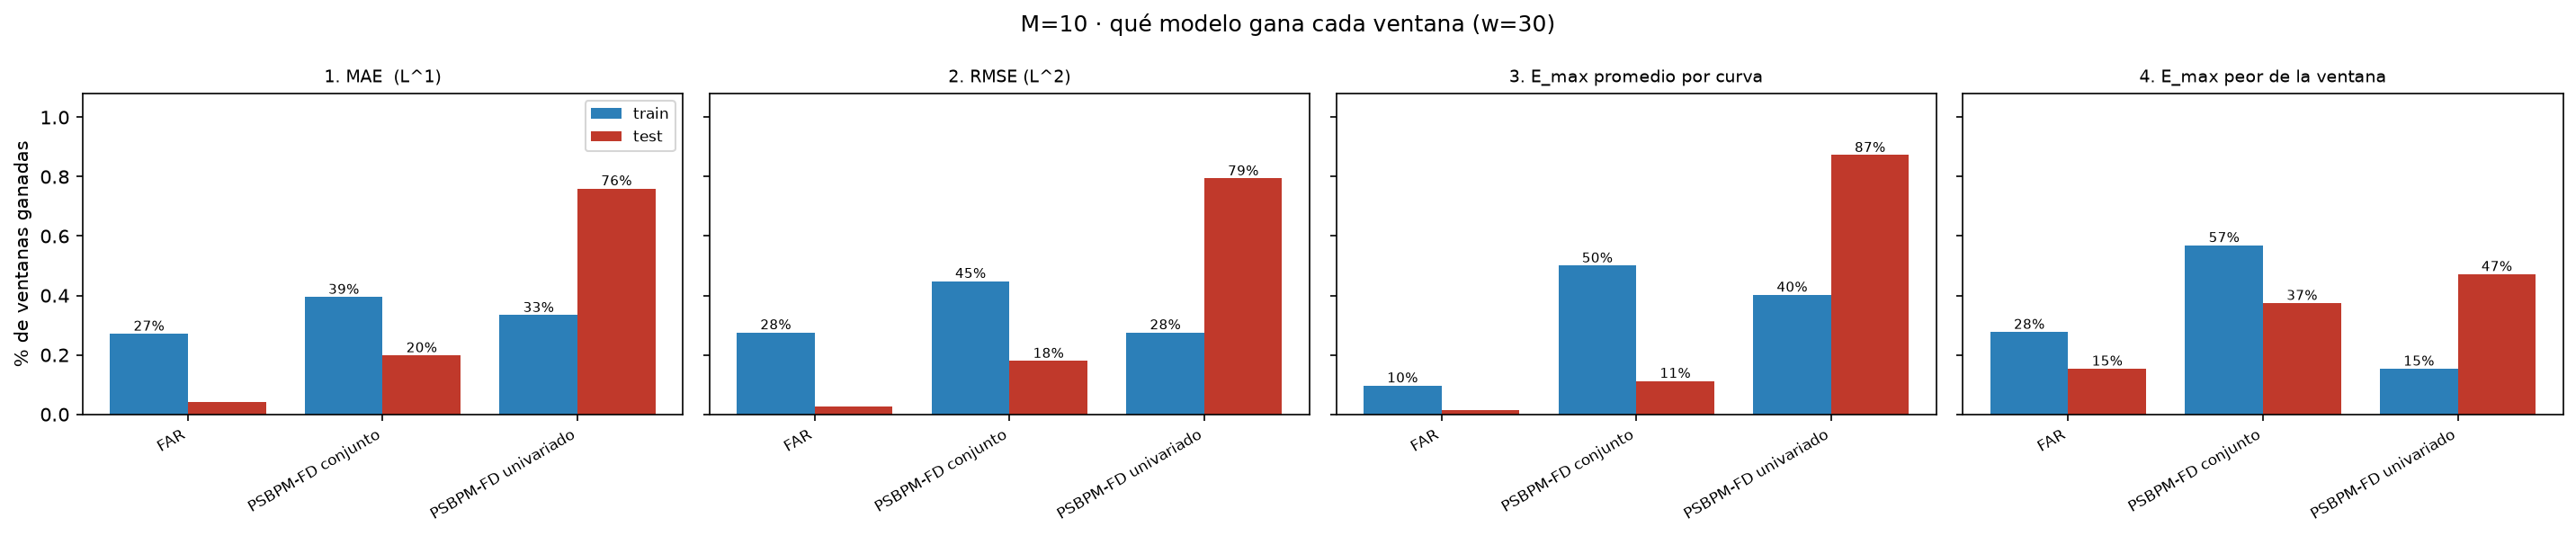

201 GARCH 77_ganador_bloqueB.png


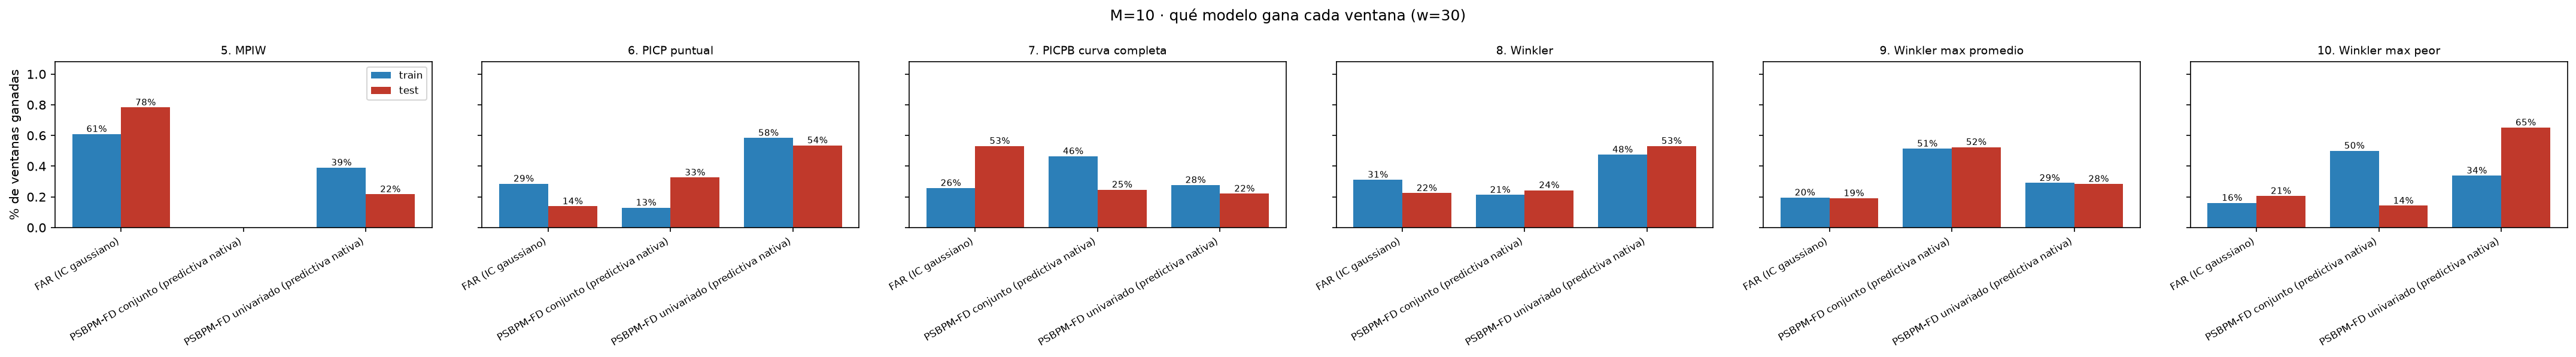

202 MULT 76_ganador_bloqueA.png


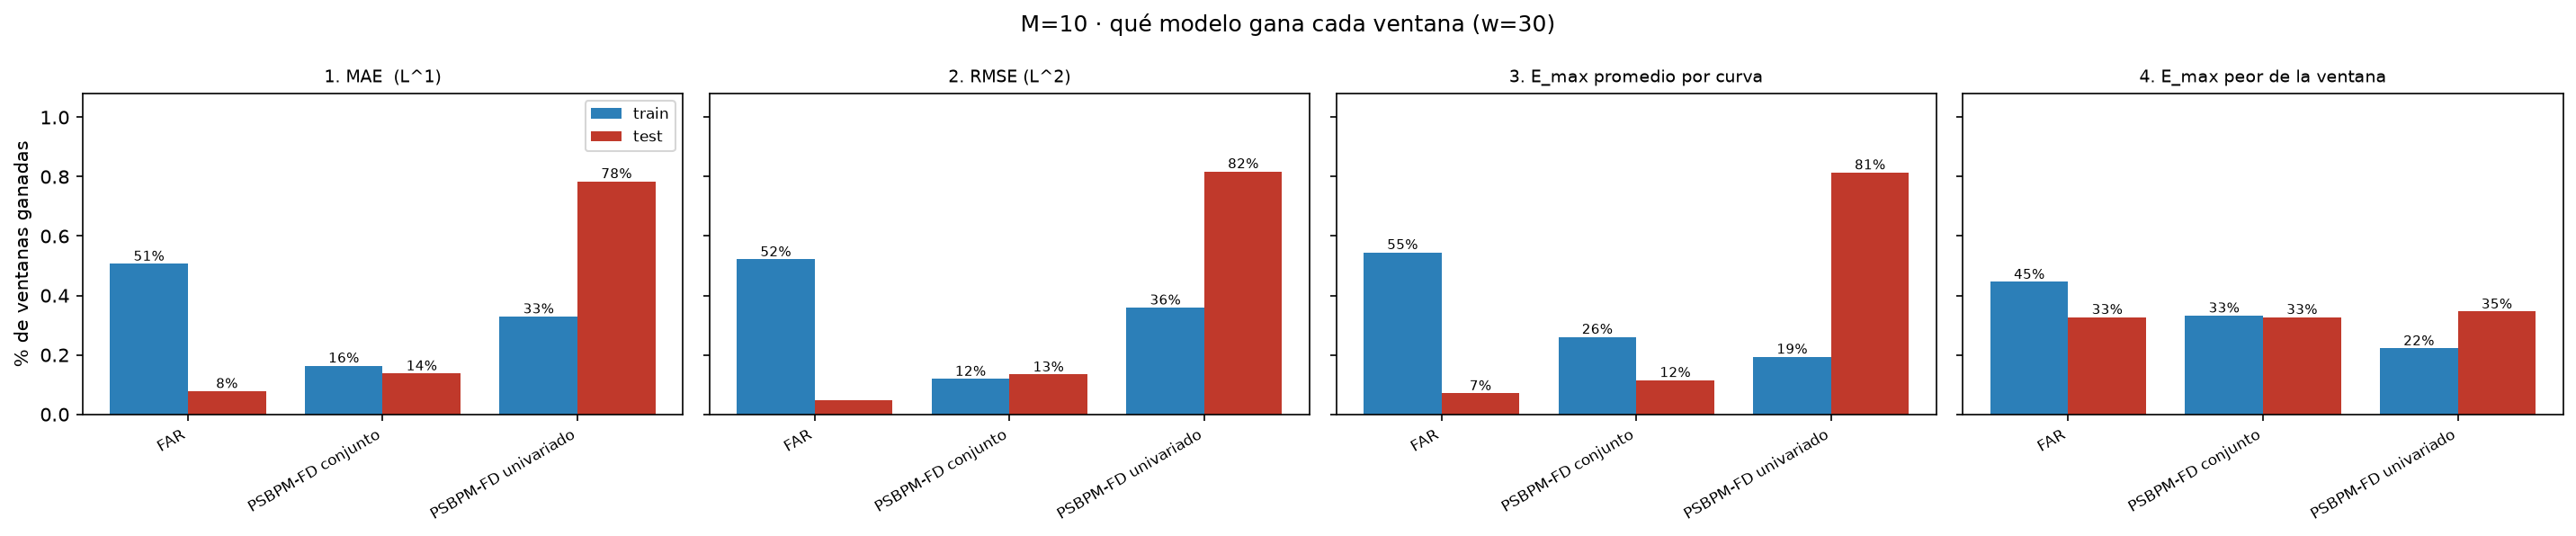

202 MULT 77_ganador_bloqueB.png


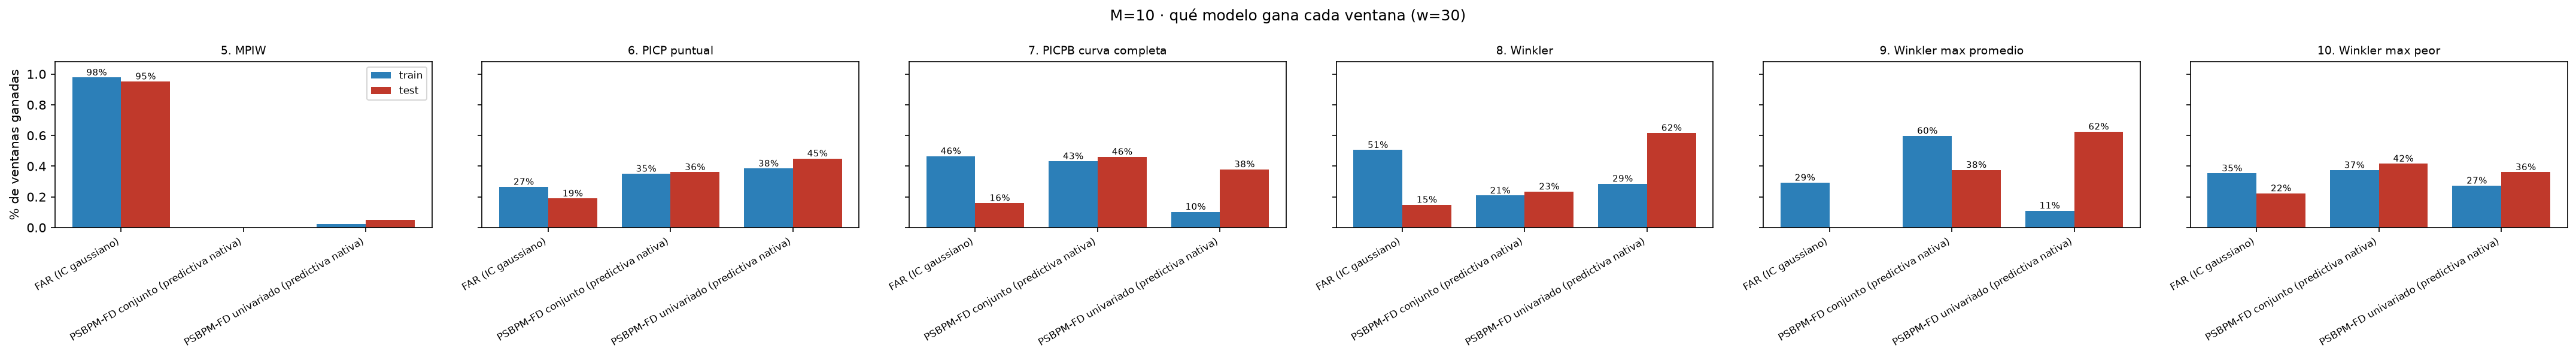

real eolica DE 76_ganador_bloqueA.png


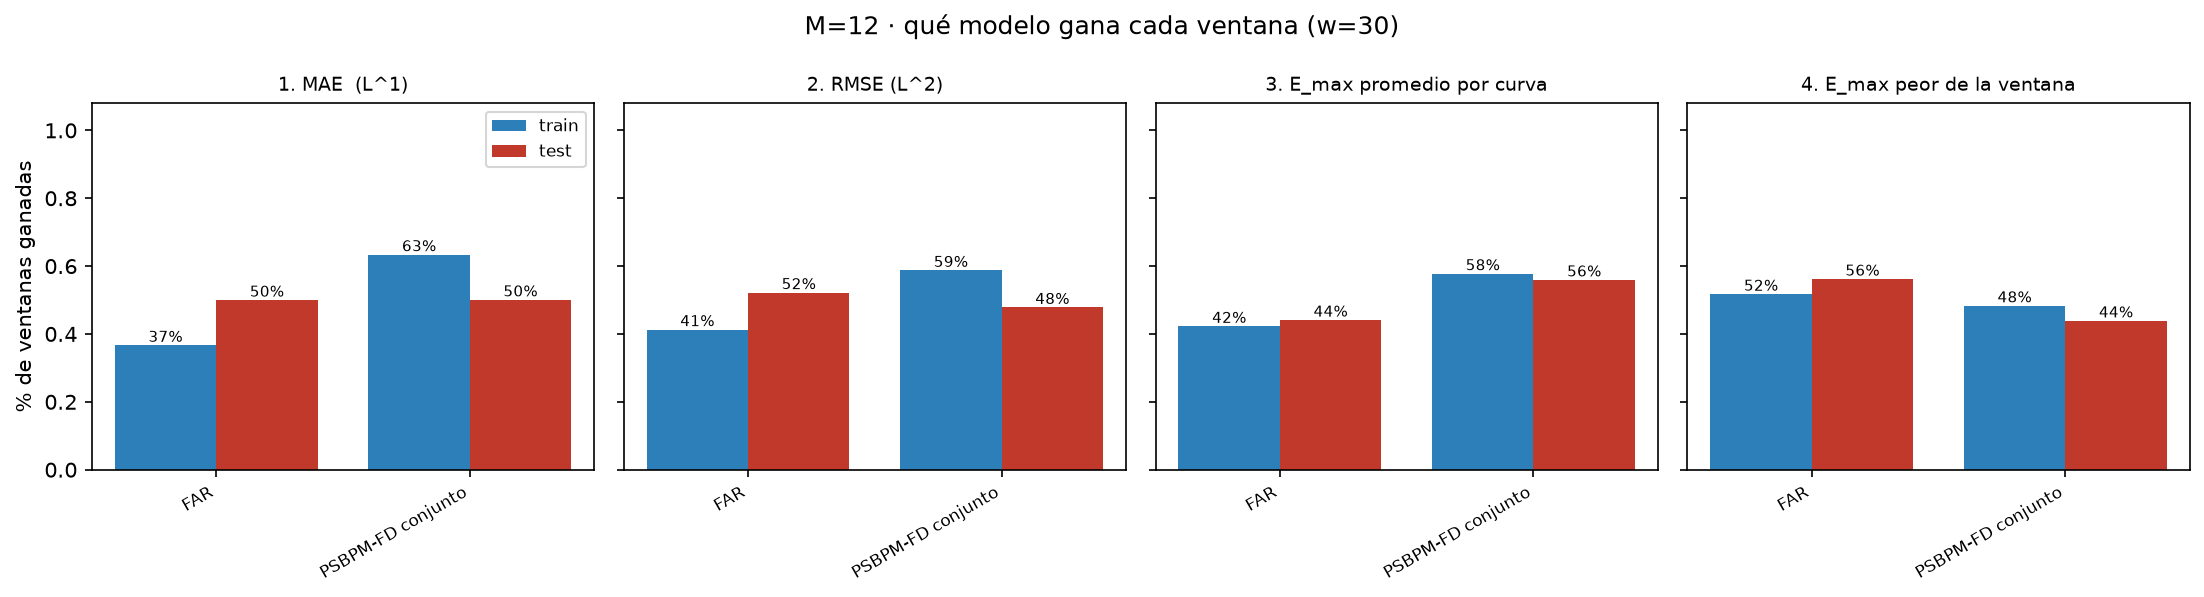

real eolica DE 77_ganador_bloqueB.png


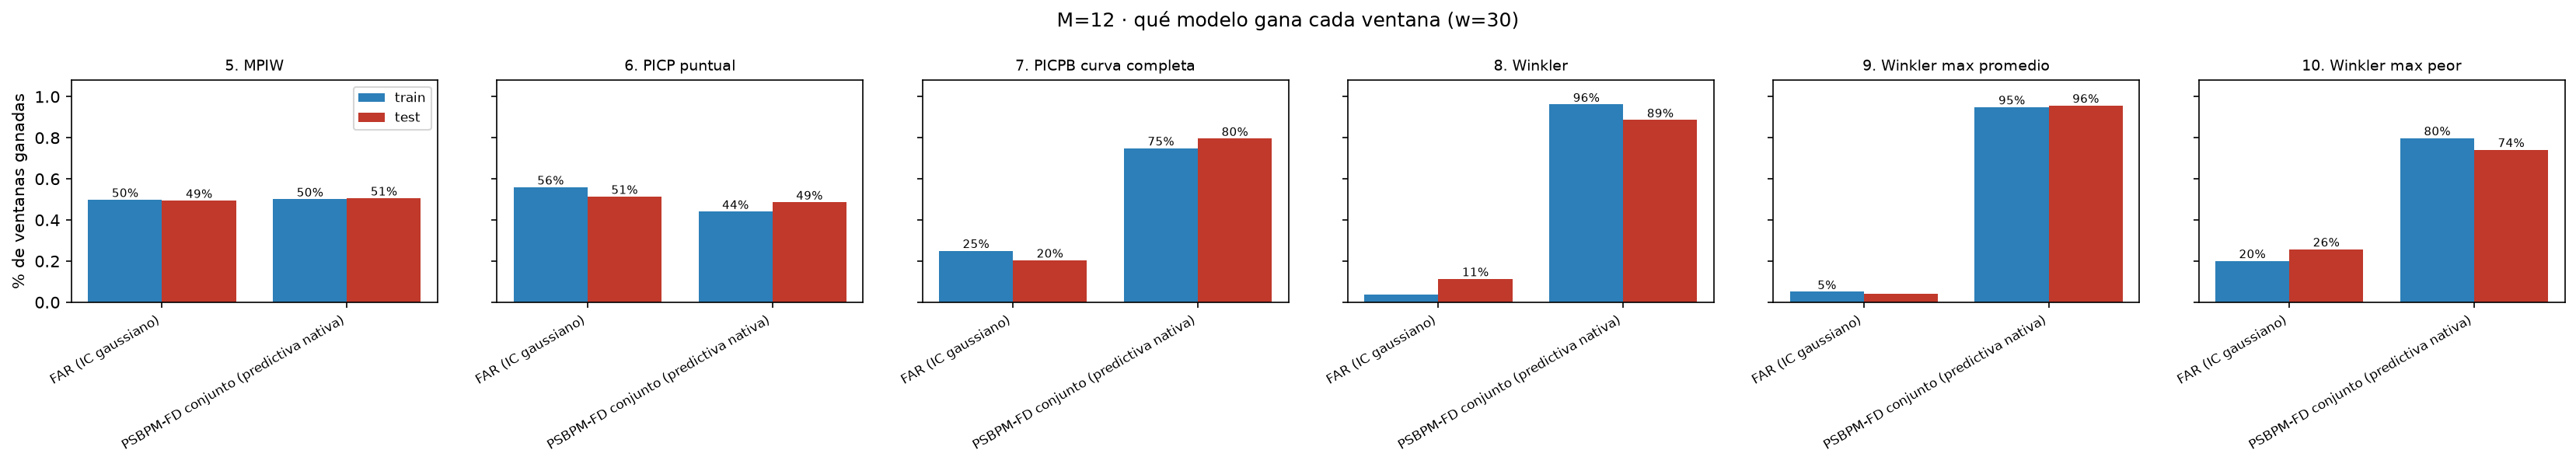

200 TAR bloque 76_ganador_bloqueA.png


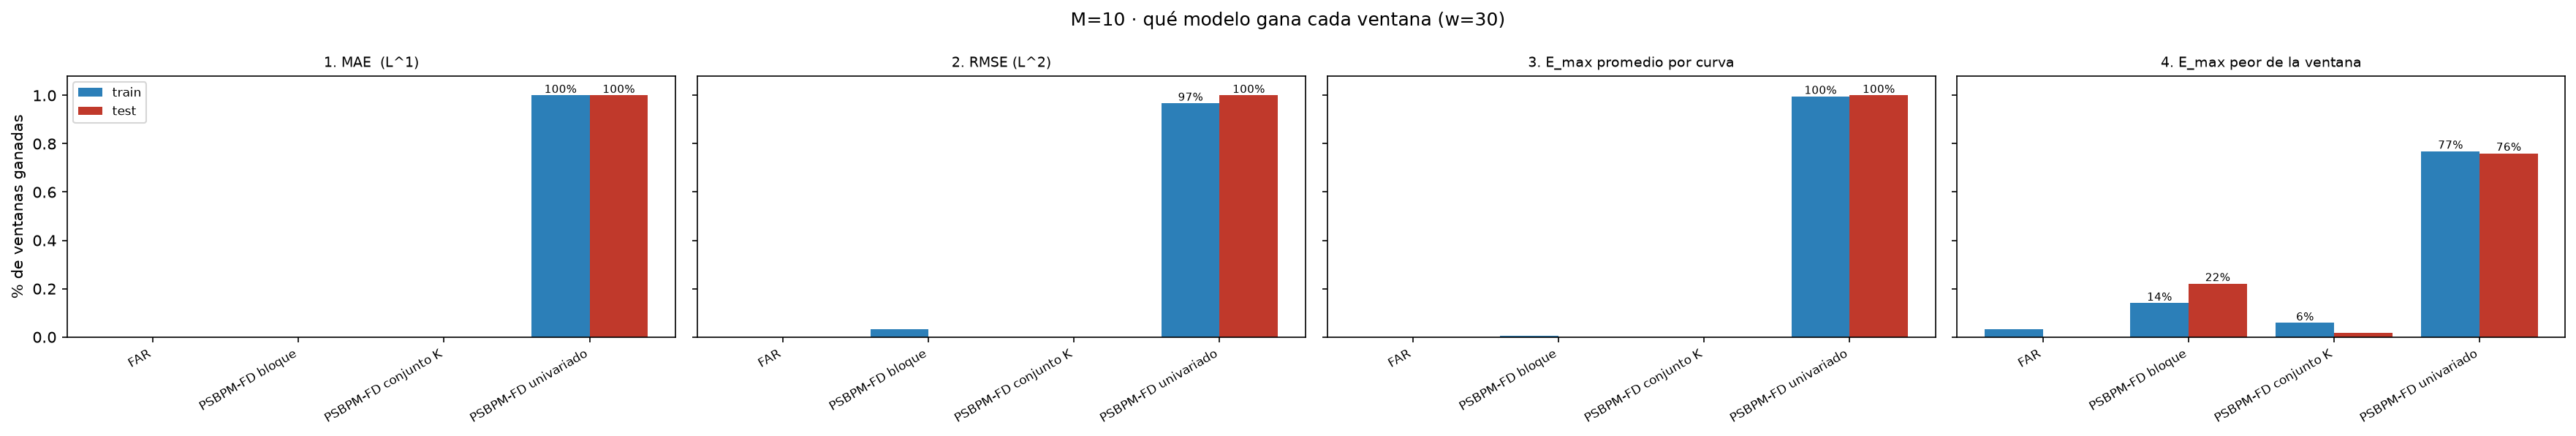

200 TAR bloque 77_ganador_bloqueB.png


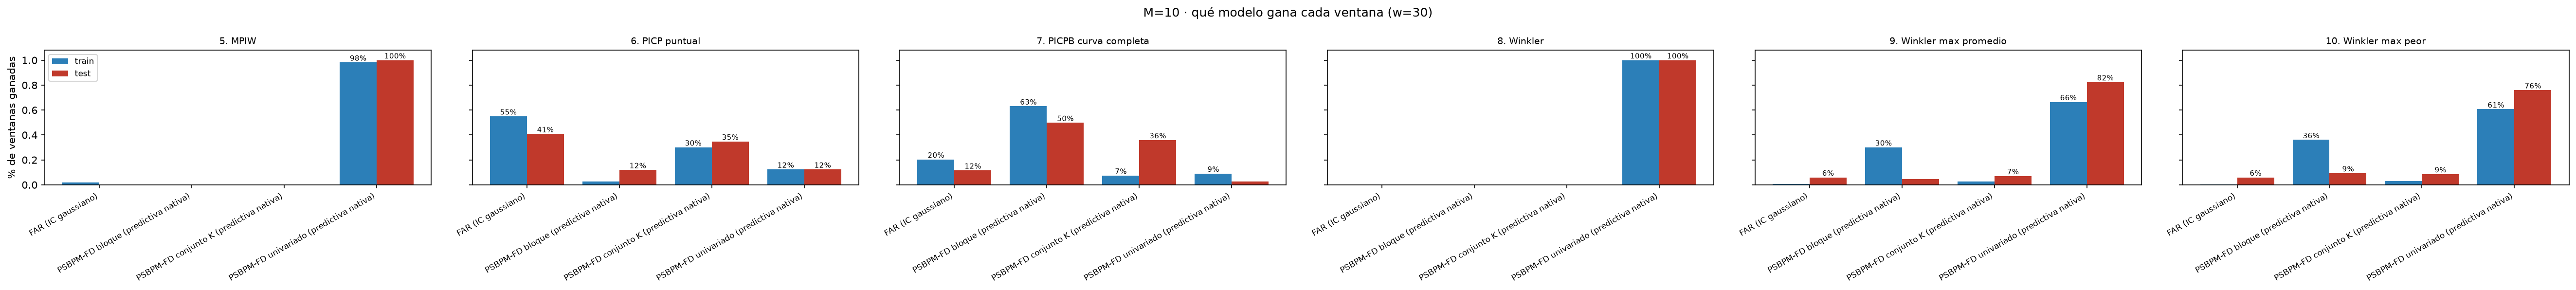

201 GARCH bloque 76_ganador_bloqueA.png


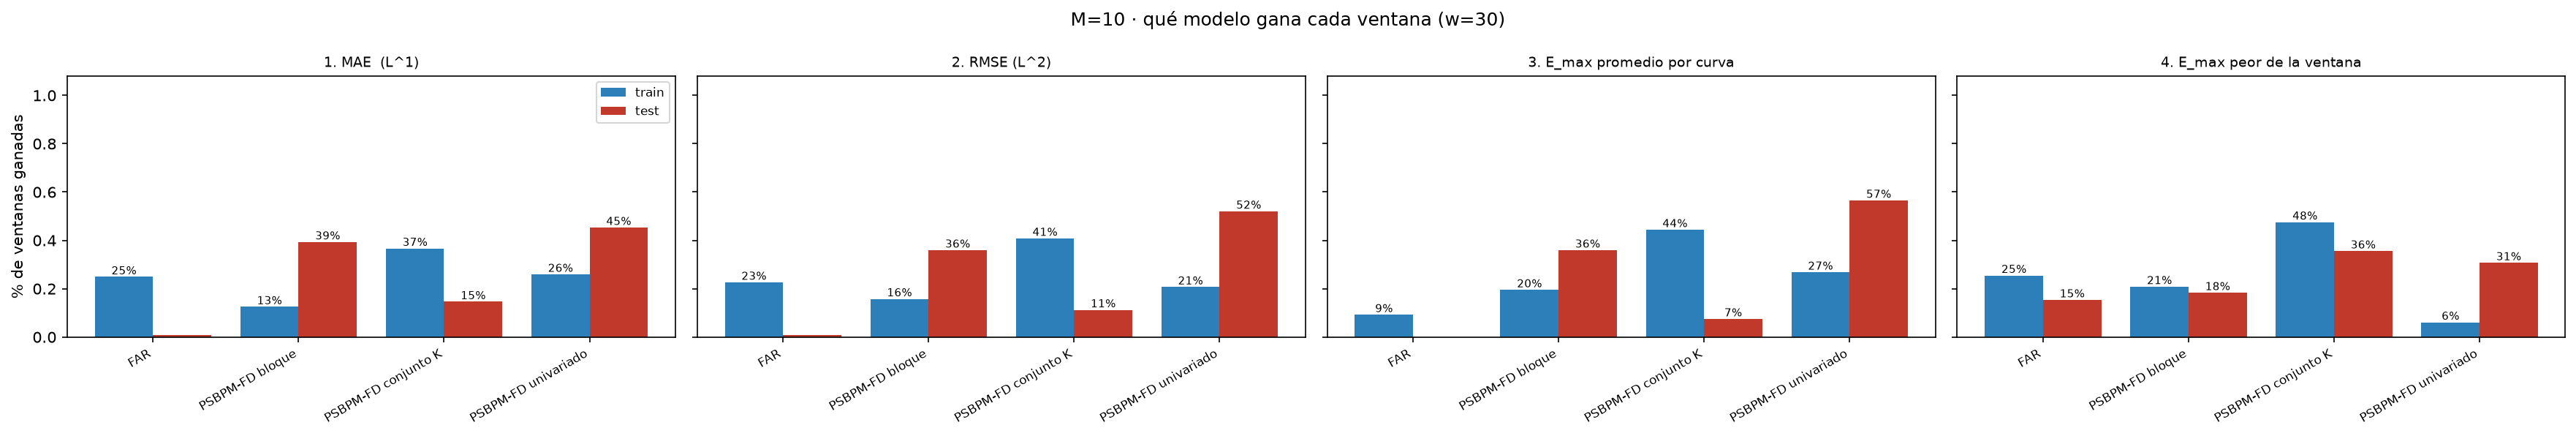

201 GARCH bloque 77_ganador_bloqueB.png


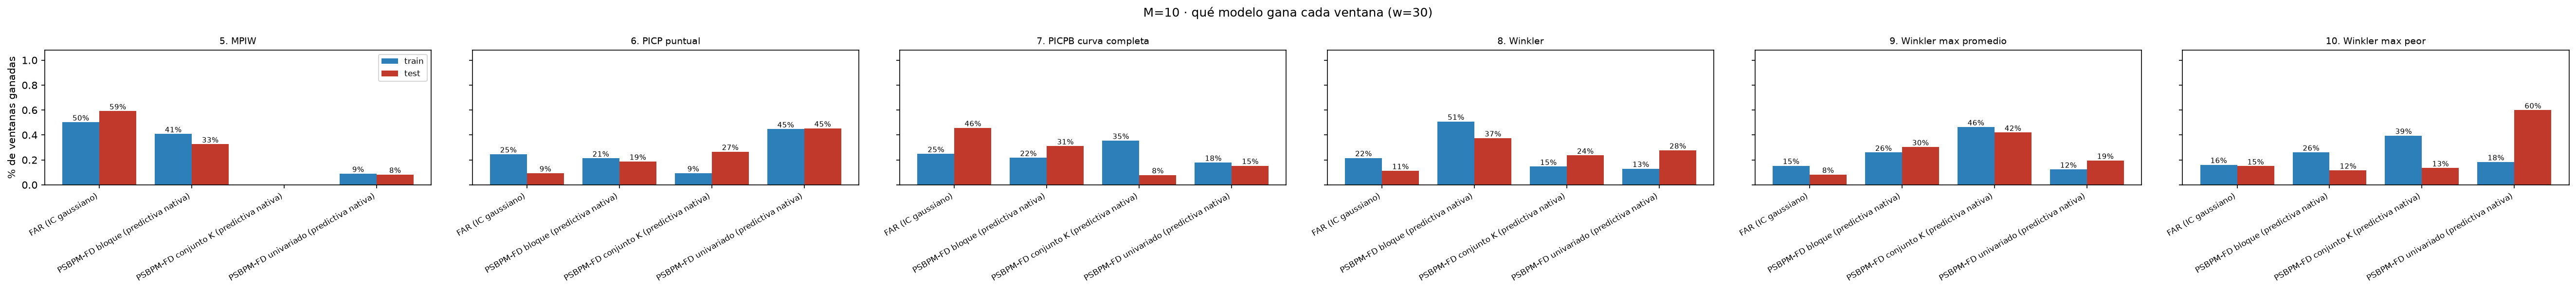

202 MULT bloque 76_ganador_bloqueA.png


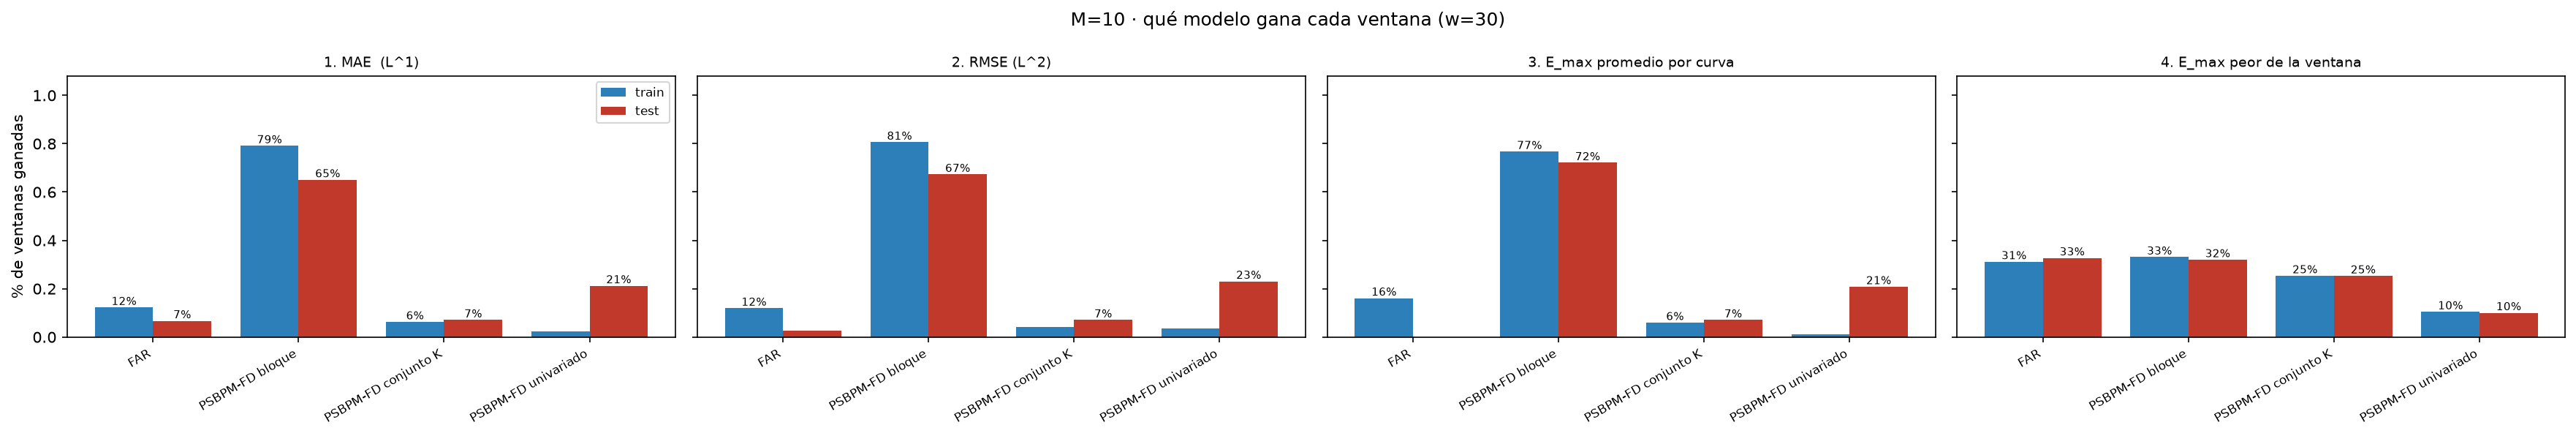

202 MULT bloque 77_ganador_bloqueB.png


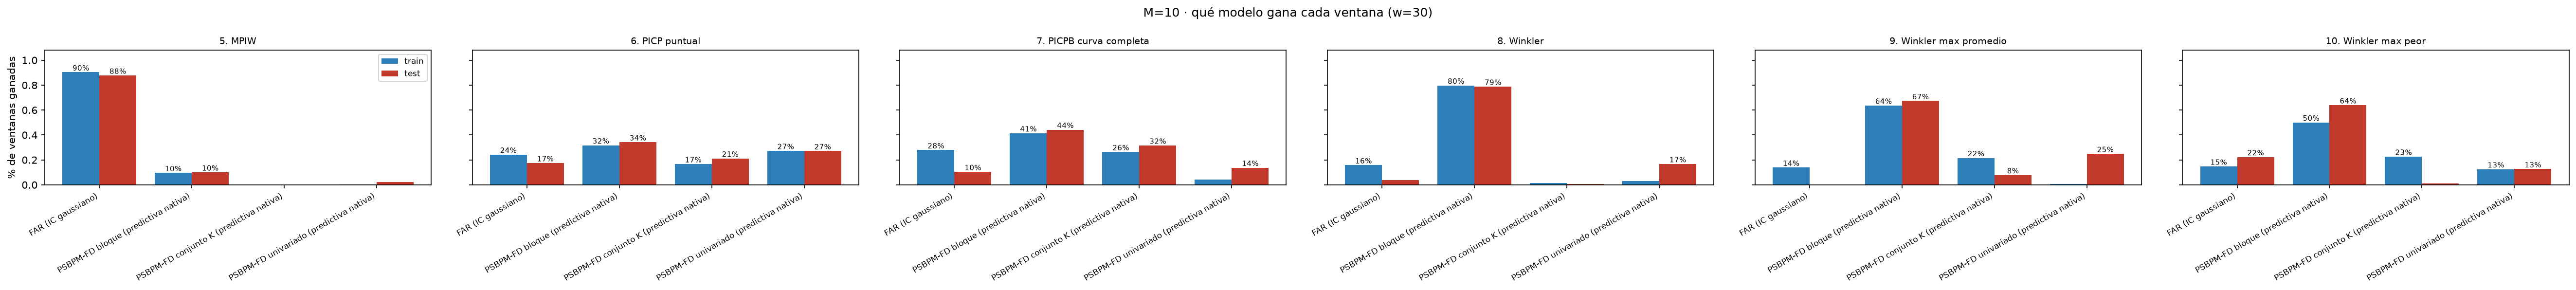

In [5]:
for caso, (dom, eid) in resumen.CASOS.items():
    for f in ("76_ganador_bloqueA.png", "77_ganador_bloqueB.png"):
        p = Path("reports") / dom / eid / f
        if p.exists():
            print(caso, f); display(Image(filename=str(p)))